In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from matplotlib.colors import ListedColormap

# Part I – Importing the Dataset and Select Versicolor and Virginica (3 pts.)

### 1.) Import the Iris data

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'        
                 'machine-learning-databases/iris/iris.data', header=None)
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### 2.) From the data set select versicolor and virginica. 

In [4]:
df = df.rename(columns={0:"sepal_length", 1:"sepal_width", 2:"petal_length", 3:"petal_width", 4: 'species'})
##df = df.query('species == "Iris-versicolor" | species == "Iris-virginica"')
#df = df.reset_index()
#df = df.drop("index", axis=1)
#
print(df)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


### 3.) 2.Choose petal width (4th feature) and sepal width (2nd feature) as features of the data.

In [5]:
df = df.drop("petal_length", axis=1)
df = df.drop("sepal_length", axis=1)
#df.species = np.where(df.species == 'Iris-versicolor', 0,1)
df['species'] = df['species'].replace(['Iris-setosa','Iris-versicolor','Iris-virginica'],['1','2','3'])
print(df)

     sepal_width  petal_width species
0            3.5          0.2       1
1            3.0          0.2       1
2            3.2          0.2       1
3            3.1          0.2       1
4            3.6          0.2       1
..           ...          ...     ...
145          3.0          2.3       3
146          2.5          1.9       3
147          3.0          2.0       3
148          3.4          2.3       3
149          3.0          1.8       3

[150 rows x 3 columns]


# Part II – Training the SVM

### 1. Split the dataset to training data and test set with 30% test size and random state=3.



In [6]:
y = df.species
X = df.drop("species", axis=1)
#y = np.where( species == 'Iris-versicolor' ,0,1)

# splitting data set with 30% test size and random state 1 for reproducibility
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=3, stratify=y)

#print("X data type\n\n",X.dtypes,"\n\ny data type\n\n", y.dtypes)
#print("length of X_train:",len(X_train),"\nlength of X_test:", len(X_test),"\nlength of y_train:", len(y_train),"\nlength of y_test:", len(y_test))
print("array X(training data set) has the values:\n\n",X,"\n\narray y(class label) has the values:\n\n", y)


array X(training data set) has the values:

      sepal_width  petal_width
0            3.5          0.2
1            3.0          0.2
2            3.2          0.2
3            3.1          0.2
4            3.6          0.2
..           ...          ...
145          3.0          2.3
146          2.5          1.9
147          3.0          2.0
148          3.4          2.3
149          3.0          1.8

[150 rows x 2 columns] 

array y(class label) has the values:

 0      1
1      1
2      1
3      1
4      1
      ..
145    3
146    3
147    3
148    3
149    3
Name: species, Length: 150, dtype: object


### 2. Implement the feature scaling method.



In [7]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print(y_train)
#print(X_train_std)

16     1
33     1
39     1
55     2
58     2
      ..
7      1
46     1
43     1
106    3
84     2
Name: species, Length: 105, dtype: object


### 3. Train the SVM by fitting the train data set using the SVC class and fit method from the sklearn.svm with linear Kernel, parameter C=1.0, and  random_state=3

In [8]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0, random_state=3)
svm.fit(X_train_std, y_train)

SVC(kernel='linear', random_state=3)

# Part IV – Evaluate the SVM Model

### 1. Count the number of misclassified samples.



In [9]:
y_pred = svm.predict(X_test_std)
print('Misclassified samples: %d' % (y_test != y_pred).sum())
#print(y_test != y_pred)

Misclassified samples: 5


### 2. Print the accuracy of the Perceptron model.

In [10]:
from sklearn.metrics import accuracy_score

print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))
print('Accuracy: %.2f' % svm.score(X_test_std, y_test))

Accuracy: 0.89
Accuracy: 0.89


# Part IV – Plotting the decision regions and the Data  (15 pts.)

### 1. Plot the different decision regions using Matplot. Set the petal length as the x-axis and the petal width as the y-axis ~done

### 2. Visualize how well the decision regions separate the different samples in the plot. Use different colors and markers for the different class labels for the scatter plot of the samples. ~ done

### 3. Highlight the test samples by encircling them with black color. ~ done

### 4. Highlight the misclassified samples by encircling them with red color. ~ done

### 5. Put a legend that labels the class types of the different shapes in the scatter plot. ~ done


<ipython-input-11-2abaf8f0d1ab>:30: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
<ipython-input-11-2abaf8f0d1ab>:34: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated since 3.2 and will be removed two minor releases later. Use an explicit list instead.
  plt.scatter(X_test[[ 41, 40, 17, 10 , 8], 0], X_test[[ 41, 40, 17, 10 , 8], 1], c='', edgecolor='red', alpha=1.0,


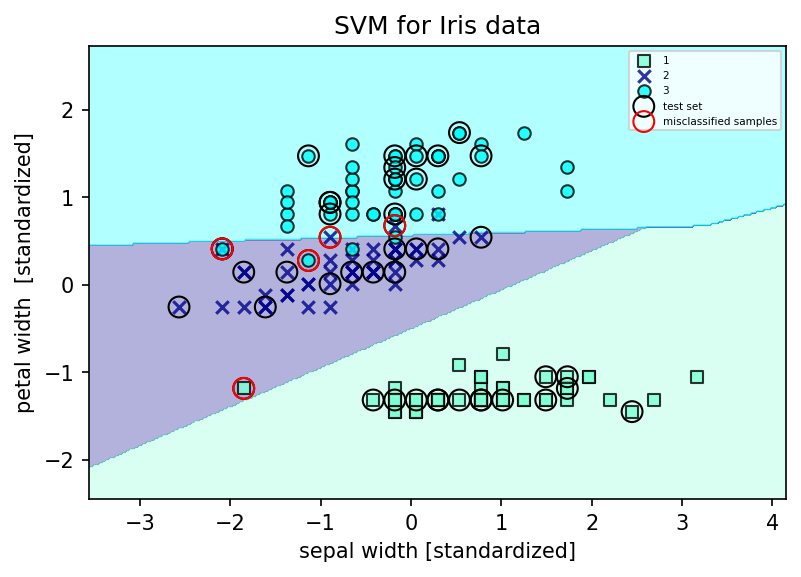

In [11]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('aquamarine', 'darkblue', 'cyan', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title('SVM for Iris data')
    
    #highlight test samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=cl, edgecolor='black')
        
    # highlight test samples - emphasize test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], c='', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o', s=100, label='test set')
    
        # highlighting the missclassified sample
        plt.scatter(X_test[[ 41, 40, 17, 10 , 8], 0], X_test[[ 41, 40, 17, 10 , 8], 1], c='', edgecolor='red', alpha=1.0,
                       linewidth=1, marker='o', s=100, label='misclassified samples')


X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))  

plt.rcParams['figure.dpi'] = 150
plot_decision_regions(X=X_combined_std, y=y_combined, classifier=svm, test_idx=range(105,150))
plt.xlabel('sepal width [standardized]')
plt.ylabel('petal width  [standardized]')
plt.legend(loc = 'upper right',prop={"size":5})
plt.show()

In [12]:
# use this to check the error rows for printing

pred_array = [y_test, y_pred, y_test != y_pred ]
dg = pd.DataFrame(y_pred)
dg = dg.assign(y_test = pd.Series(y_test).values)
dg = dg.assign(missclassified = pd.Series(y_test != y_pred).values)
dg = dg.assign(x_test_std_0 = pd.Series(X_test_std[:,0]).values)
dg = dg.assign(x_test_std_1 = pd.Series(X_test_std[:,1]).values)
print(dg)

    0 y_test  missclassified  x_test_std_0  x_test_std_1
0   1      1           False      0.297909     -1.316762
1   3      3           False      0.775473      1.475026
2   1      1           False      1.730601     -1.183819
3   2      2           False     -0.418437      0.145603
4   2      2           False      0.297909      0.411488
5   3      3           False     -0.179655      1.475026
6   1      1           False     -0.418437     -1.316762
7   2      2           False     -2.089911      0.411488
8   2      3            True     -1.134783      0.278546
9   2      2           False      0.059127      0.411488
10  3      2            True     -0.896001      0.544430
11  1      1           False      1.014255     -1.316762
12  2      2           False     -0.179655      0.145603
13  2      2           False     -2.567474     -0.253223
14  2      2           False     -1.612347     -0.253223
15  3      3           False     -0.179655      1.342084
16  3      3           False   